# B-mode Radiomics Demo

Simple medical-user-friendly interface for B-mode first-order and GLCM radiomics with phantom normalisation.

Upload your RF scan window and phantom window to get normalised features.

In [149]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sys
import time
import io

# Add the submodule root to path so "quantus." imports work
sys.path.insert(0, str(Path.cwd().parent))

from quantus.analysis.bmode.functions import (
    _get_log_envelope,
    _build_radiomics_image_and_mask,
    _make_extractor,
    _extract_feature,
    _safe_ratio
)

print("B-mode radiomics helpers loaded successfully")

B-mode radiomics helpers loaded successfully


## Quick Demo Mode

Run this cell to create synthetic RF data for testing.

In [150]:
# Quick Demo Mode - creates synthetic RF data
np.random.seed(42)

rf_scan = np.random.randn(128, 64).astype(np.float32) * 0.5 + 2.0
rf_phantom = np.random.randn(128, 64).astype(np.float32) * 0.6 + 1.8

print(f"Demo data ready (scan: {rf_scan.shape}, phantom: {rf_phantom.shape})")

# Run analysis
results_dict = run_bmode_radiomics(rf_scan, rf_phantom)
print("Analysis complete with demo data")

Demo data ready (scan: (128, 64), phantom: (128, 64))
Analysis complete with demo data


## 1. Load RF data
Upload or select your scan and phantom RF windows (numpy .npy files).

In [151]:
from ipywidgets import FileUpload

print("Upload SCAN RF window (2D numpy array)")
scan_upload = FileUpload(accept='.npy', multiple=False)
display(scan_upload)

print("\nUpload PHANTOM RF window (same shape)")
phantom_upload = FileUpload(accept='.npy', multiple=False)
display(phantom_upload)

Upload SCAN RF window (2D numpy array)


FileUpload(value=(), accept='.npy', description='Upload')


Upload PHANTOM RF window (same shape)


FileUpload(value=(), accept='.npy', description='Upload')

In [155]:
import time

def load_rf(upload_widget):
    if not upload_widget.value:
        raise ValueError("No file uploaded")
    
    time.sleep(0.5)
    
    uploaded = upload_widget.value
    if isinstance(uploaded, tuple) and len(uploaded) > 0:
        uploaded = uploaded[0]
    elif isinstance(uploaded, dict):
        uploaded = list(uploaded.values())[0]
    
    content = uploaded['content']
    rf = np.load(io.BytesIO(content))
    return rf.astype(np.float32)

# Run this cell AFTER uploading both files
try:
    rf_scan = load_rf(scan_upload)
    rf_phantom = load_rf(phantom_upload)
    print(f"Loaded scan: {rf_scan.shape} | phantom: {rf_phantom.shape}")
except Exception as e:
    print(f"Error: {str(e)}")
    print("Please upload both files first, wait 1 second, then run this cell again.")

Loaded scan: (128, 64) | phantom: (128, 64)


In [156]:
# List of features we want (uses Variance to avoid deprecation warning)
FEATURES = {
    "firstorder": ["Mean", "Variance", "Median", "Entropy", "Energy", "InterquartileRange"],
    "glcm": ["Contrast", "Idm", "Correlation", "JointEnergy"]
}

def run_bmode_radiomics(rf_scan, rf_phantom):
    results = {}
    
    for name, rf in [("scan", rf_scan), ("phantom", rf_phantom)]:
        log_env = _get_log_envelope(rf)
        image, mask = _build_radiomics_image_and_mask(log_env)
        
        for family, feature_list in FEATURES.items():
            extractor = _make_extractor(family, feature_list)
            for feat in feature_list:
                if family == "firstorder":
                    key = f"original_firstorder_{feat}"
                else:
                    key = f"original_glcm_{feat}"
                
                val = _extract_feature(extractor, rf, key)
                
                if family == "firstorder" and feat == "Variance":
                    val = np.sqrt(val) if val is not None and not np.isnan(val) else np.nan
                
                results[f"{name}_{family}_{feat.lower()}"] = val
    
    final_results = {}
    for family, feature_list in FEATURES.items():
        for feat in feature_list:
            key = f"{family}_{feat.lower()}"
            scan_val = results[f"scan_{key}"]
            phantom_val = results[f"phantom_{key}"]
            final_key = key.replace("variance", "standarddeviation")
            final_results[final_key] = _safe_ratio(scan_val, phantom_val)
    
    return final_results

# Run the analysis
if 'rf_scan' in globals() and 'rf_phantom' in globals():
    results_dict = run_bmode_radiomics(rf_scan, rf_phantom)
    print("Analysis complete")
else:
    print("Upload files first, then run this cell")

Analysis complete


## 2. Results

,Feature,Normalised Value (scan/phantom)
0,firstorder_mean,0.8331
1,firstorder_standarddeviation,1.3541
2,firstorder_median,0.8812
3,firstorder_entropy,1.3753
4,firstorder_energy,1.2588
5,firstorder_interquartilerange,1.4865
6,glcm_contrast,1.2403
7,glcm_idm,0.9677
8,glcm_correlation,-10.8330
9,glcm_jointenergy,0.7490


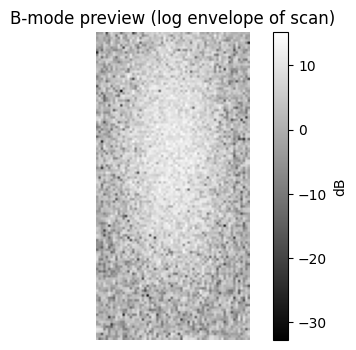

In [157]:
if 'results_dict' in globals():
    df = pd.DataFrame(list(results_dict.items()), columns=["Feature", "Normalised Value (scan/phantom)"])
    display(df.style.set_caption("B-mode Radiomics Features").format(precision=4))
    
    # B-mode preview
    log_env = _get_log_envelope(rf_scan)
    plt.figure(figsize=(6,4))
    plt.imshow(log_env, cmap='gray')
    plt.title("B-mode preview (log envelope of scan)")
    plt.colorbar(label='dB')
    plt.axis('off')
    plt.show()
else:
    print("Run the analysis cell first")